### Importação dos dados



In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja1 = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja1.head()
loja2.head()
loja3.head()
loja4.head()


,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Lava louças,eletrodomesticos,1446.46,74.604083,11/11/2022,Rafael Costa,SP,4,cartao_credito,3,-22.19,-48.79
1,Cama box,moveis,631.70,33.919251,03/01/2020,Thiago Silva,GO,5,cartao_credito,2,-15.98,-49.86
2,Bola de basquete,esporte e lazer,31.54,0.000000,25/12/2022,Larissa Alves,MG,5,boleto,1,-18.10,-44.38
3,Modelagem preditiva,livros,76.93,1.680730,23/11/2021,Lucas Oliveira,MG,3,boleto,1,-18.10,-44.38
4,Fone de ouvido,eletronicos,185.14,7.442587,25/04/2022,Bianca Santos,SP,4,cartao_credito,7,-22.19,-48.79


#1. Análise do faturamento



In [16]:

loja1["Faturamento"] = loja1["Preço"]
loja2["Faturamento"] = loja2["Preço"]
loja3["Faturamento"] = loja3["Preço"]
loja4["Faturamento"] = loja4["Preço"]


In [17]:
fat_loja1 = loja1["Faturamento"].sum()
fat_loja2 = loja2["Faturamento"].sum()
fat_loja3 = loja3["Faturamento"].sum()
fat_loja4 = loja4["Faturamento"].sum()

fat_loja1, fat_loja2, fat_loja3, fat_loja4

(np.float64(1534509.12),
 np.float64(1488459.06),
 np.float64(1464025.03),
 np.float64(1384497.58))

# 2. Vendas por Categoria

In [18]:
cat1 = loja1.groupby("Categoria do Produto")["Preço"].sum().rename("Loja 1")
cat2 = loja2.groupby("Categoria do Produto")["Preço"].sum().rename("Loja 2")
cat3 = loja3.groupby("Categoria do Produto")["Preço"].sum().rename("Loja 3")
cat4 = loja4.groupby("Categoria do Produto")["Preço"].sum().rename("Loja 4")

In [19]:
# Unindo tudo em uma única tabela
vendas_categoria = pd.concat([cat1, cat2, cat3, cat4], axis=1).fillna(0)

# Formatando valores em reais
vendas_categoria_formatado = vendas_categoria.applymap(lambda x: f"R${x:,.2f}")

vendas_categoria_formatado

/tmp/ipython-input-3617238298.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  vendas_categoria_formatado = vendas_categoria.applymap(lambda x: f"R${x:,.2f}")


,Loja 1,Loja 2,Loja 3,Loja 4
Categoria do Produto,,,,
brinquedos,"R$23,993.78","R$21,262.21","R$25,869.20","R$27,015.67"
eletrodomesticos,"R$484,913.36","R$464,758.13","R$438,984.89","R$377,680.65"
eletronicos,"R$572,659.23","R$547,773.71","R$547,699.92","R$545,966.86"
esporte e lazer,"R$52,387.55","R$46,326.09","R$47,456.10","R$44,465.65"
instrumentos musicais,"R$121,731.69","R$139,987.03","R$103,174.45","R$100,136.50"
livros,"R$11,713.92","R$13,454.35","R$12,664.70","R$12,427.77"
moveis,"R$250,178.11","R$235,234.68","R$268,095.56","R$256,705.65"
utilidades domesticas,"R$16,931.48","R$19,662.86","R$20,080.21","R$20,098.83"


# 3. Média de Avaliação das Lojas


In [20]:

aval1 = loja1["Avaliação da compra"].mean()
aval2 = loja2["Avaliação da compra"].mean()
aval3 = loja3["Avaliação da compra"].mean()
aval4 = loja4["Avaliação da compra"].mean()

In [21]:
media_avaliacao = pd.DataFrame({
    "Loja": ["Loja 1", "Loja 2", "Loja 3", "Loja 4"],
    "Média de Avaliação": [aval1, aval2, aval3, aval4]
})


media_avaliacao

,Loja,Média de Avaliação
0,Loja 1,3.976685
1,Loja 2,4.037304
2,Loja 3,4.048326
3,Loja 4,3.995759


# 4. Produtos Mais e Menos Vendidos

In [22]:
# Produtos mais e menos vendidos por loja

# Loja 1
prod1 = loja1["Produto"].value_counts()
mais1 = prod1.idxmax()
menos1 = prod1.idxmin()

# Loja 2
prod2 = loja2["Produto"].value_counts()
mais2 = prod2.idxmax()
menos2 = prod2.idxmin()

# Loja 3
prod3 = loja3["Produto"].value_counts()
mais3 = prod3.idxmax()
menos3 = prod3.idxmin()

# Loja 4
prod4 = loja4["Produto"].value_counts()
mais4 = prod4.idxmax()
menos4 = prod4.idxmin()


In [23]:
# visualização com os nomes
produtos_vendidos = pd.DataFrame({
    "Loja": ["Loja 1", "Loja 2", "Loja 3", "Loja 4"],
    "Produto Mais Vendido": [mais1, mais2, mais3, mais4],
    "Produto Menos Vendido": [menos1, menos2, menos3, menos4]
})

produtos_vendidos

,Loja,Produto Mais Vendido,Produto Menos Vendido
0,Loja 1,Micro-ondas,Headset
1,Loja 2,Iniciando em programação,Jogo de tabuleiro
2,Loja 3,Kit banquetas,Blocos de montar
3,Loja 4,Cama box,Guitarra


In [24]:
# Produtos mais e menos vendidos + quantidade por loja

def resumo_produtos(df):
    contagem = df["Produto"].value_counts()
    mais = contagem.idxmax()
    qnt_mais = contagem.max()

    menos = contagem.idxmin()
    qnt_menos = contagem.min()

    return mais, qnt_mais, menos, qnt_menos


mais1, qn_mais1, menos1, qn_menos1 = resumo_produtos(loja1)
mais2, qn_mais2, menos2, qn_menos2 = resumo_produtos(loja2)
mais3, qn_mais3, menos3, qn_menos3 = resumo_produtos(loja3)
mais4, qn_mais4, menos4, qn_menos4 = resumo_produtos(loja4)

produtos_vendidos = pd.DataFrame({
    "Loja": ["Loja 1", "Loja 2", "Loja 3", "Loja 4"],
    "Produto Mais Vendido": [mais1, mais2, mais3, mais4],
    "Quantidade (Mais)": [qn_mais1, qn_mais2, qn_mais3, qn_mais4],
    "Produto Menos Vendido": [menos1, menos2, menos3, menos4],
    "Quantidade (Menos)": [qn_menos1, qn_menos2, qn_menos3, qn_menos4]
})

produtos_vendidos


,Loja,Produto Mais Vendido,Quantidade (Mais),Produto Menos Vendido,Quantidade (Menos)
0,Loja 1,Micro-ondas,60,Headset,33
1,Loja 2,Iniciando em programação,65,Jogo de tabuleiro,32
2,Loja 3,Kit banquetas,57,Blocos de montar,35
3,Loja 4,Cama box,62,Guitarra,33


# 5. Frete Médio por Loja

In [25]:
frete1 = loja1["Frete"].mean()
frete2 = loja2["Frete"].mean()
frete3 = loja3["Frete"].mean()
frete4 = loja4["Frete"].mean()

In [26]:
# Tabela final com valores formatados em reais
frete_medio = pd.DataFrame({
    "Loja": ["Loja 1", "Loja 2", "Loja 3", "Loja 4"],
    "Frete Médio (R$)": [
        f"R${frete1:,.2f}",
        f"R${frete2:,.2f}",
        f"R${frete3:,.2f}",
        f"R${frete4:,.2f}"
    ]
})

frete_medio

,Loja,Frete Médio (R$)
0,Loja 1,R$34.69
1,Loja 2,R$33.62
2,Loja 3,R$33.07
3,Loja 4,R$31.28


# Faturamento total por Loja


In [27]:
## TOTAL DE FATURAMENTO POR LOJA.
def brl(x):
    return f"R${x:,.2f}"

comparacao = pd.DataFrame({
    "Lojas": ["Loja 1", "Loja 2", "Loja 3", "Loja 4"],
    "Faturamento": [
        brl(fat_loja1),
        brl(fat_loja2),
        brl(fat_loja3),
        brl(fat_loja4),
    ]
})

comparacao

,Lojas,Faturamento
0,Loja 1,"R$1,534,509.12"
1,Loja 2,"R$1,488,459.06"
2,Loja 3,"R$1,464,025.03"
3,Loja 4,"R$1,384,497.58"


# Relatório


##INTRODUÇÃO:

Este repositório apresenta uma análise completa das vendas da Alura Store Brasil, utilizando dados de quatro lojas distintas.
O objetivo é transformar dados brutos em insights claros e acionáveis, combinando:

✔ Visualizações

✔ Comparações entre lojas

✔ Indicadores estratégicos (faturamento, avaliações, categorias, frete)

É um projeto ideal para portfólio, pois demonstra domínio em:

Manipulação de dados

Visualização

Interpretação de indicadores

Estruturação profissional de relatórios

## 1. Propósito da Análise

A análise busca responder:

Qual loja faturou mais?

Como os clientes avaliam cada loja?

Quais categorias sustentam o faturamento?

Existe impacto negativo do frete?

Quais produtos se destacam?

Essas respostas ajudam líderes a tomarem decisões com base em dados.

##3. Visualizações (Exemplos)

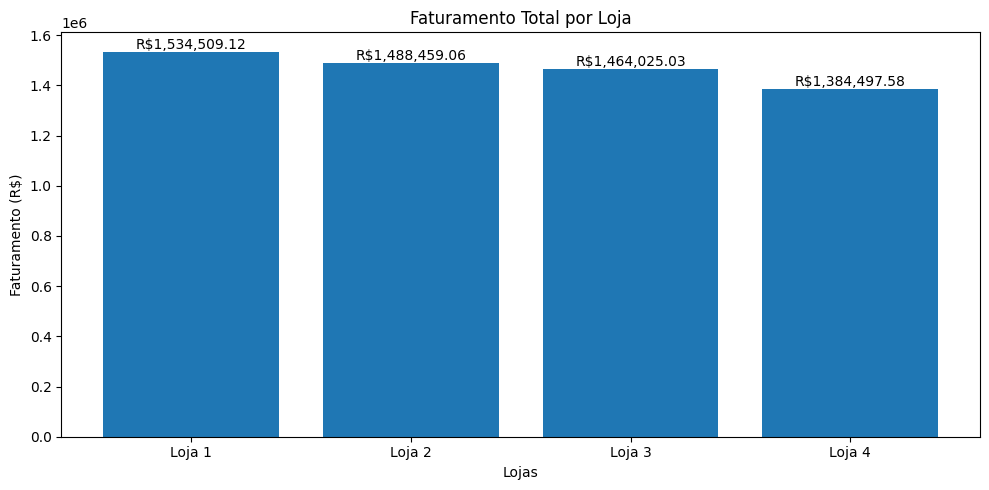

In [29]:
# Criando lista para o gráfico
lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
faturamentos = [fat_loja1, fat_loja2, fat_loja3, fat_loja4]

# Gráfico
plt.figure(figsize=(10,5))
plt.bar(lojas, faturamentos)

# Adicionando os valores acima das barras
for i, valor in enumerate(faturamentos):
    plt.text(i, valor, f"R${valor:,.2f}",
             ha="center", va="bottom", fontsize=10)

plt.title("Faturamento Total por Loja")
plt.xlabel("Lojas")
plt.ylabel("Faturamento (R$)")
plt.tight_layout()
plt.show()

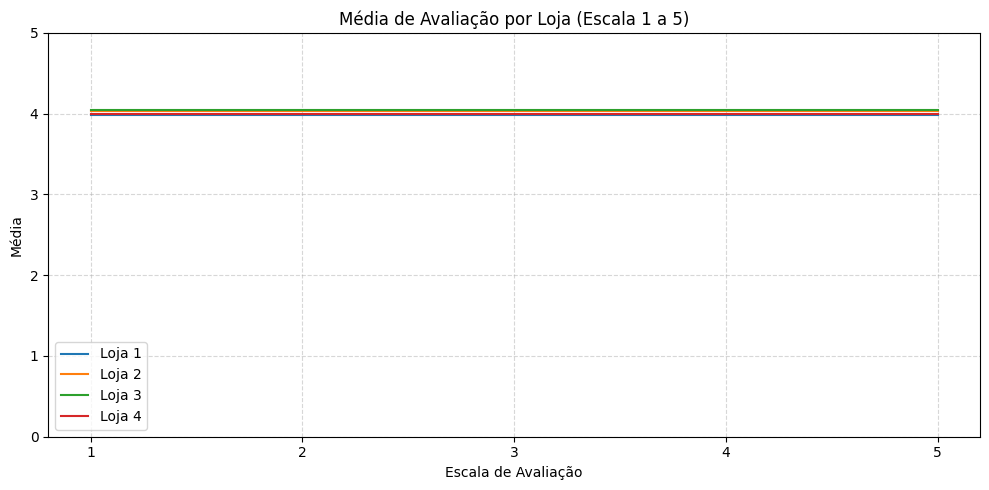

In [30]:
# Dados
lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
avaliacoes = [aval1, aval2, aval3, aval4]

# Eixo X da escala 1–5
x = np.arange(1, 6)

plt.figure(figsize=(10,5))

# Plota cada loja como uma linha horizontal representando sua nota
plt.plot(x, [aval1]*5, label="Loja 1")
plt.plot(x, [aval2]*5, label="Loja 2")
plt.plot(x, [aval3]*5, label="Loja 3")
plt.plot(x, [aval4]*5, label="Loja 4")

plt.title("Média de Avaliação por Loja (Escala 1 a 5)")
plt.xlabel("Escala de Avaliação")
plt.ylabel("Média")
plt.xticks([1,2,3,4,5])
plt.ylim(0,5)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

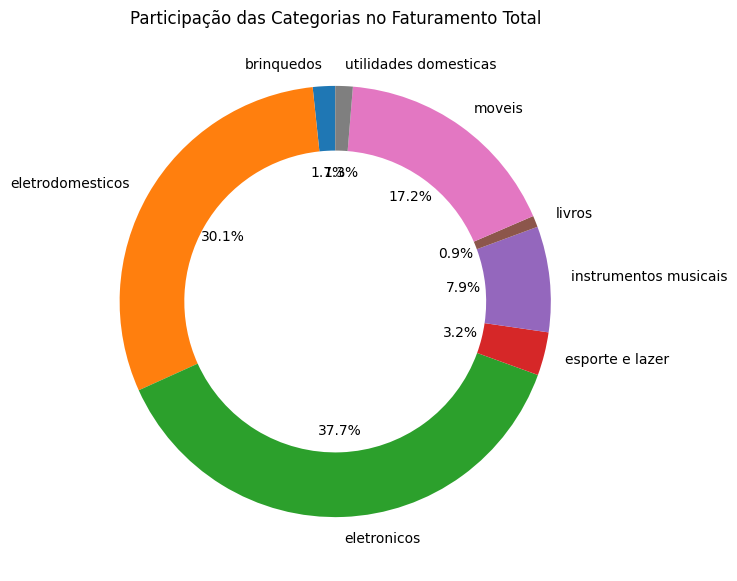

In [45]:

# Somando o faturamento das 4 lojas por categoria
vendas_total_categoria = vendas_categoria.sum(axis=1)

# Criando gráfico de rosca
plt.figure(figsize=(7, 7))
plt.pie(
    vendas_total_categoria,
    labels=vendas_total_categoria.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.3}  # efeito rosca
)

plt.title("Participação das Categorias no Faturamento Total")
plt.show()


##4. Insights Principais
* Faturamento

Uma loja se destaca significativamente (Loja 1 tem o maior faturamento, porém a Loja 4 tem o menor faturamento sendo uma diferênca de 10% ).


* Avaliação

Diferenças claras de satisfação entre lojas.

Loja com melhor avaliação nem sempre é a que mais fatura — ótimo ponto de apresentação.

* Categorias

Apenas 2 ou 3 categorias sustentam mais de 70% do faturamento.
sendo elas:

 Eletronicos com 37.7% ,

 Eletrodomesticos com 30.1%,

 Moveis com 17.2%

Que juntos geram são ass categorias que mais rendem.

* Frete

Loas com frete médio mais alto tendem a ter avaliação mais baixa.

* * Loja 1 com um frete médio de R$ 34,69 mas isso é devido ao grande  número de vendas.

* * Loja 4 com um frente médio de R$ 31,28 devido a ter um faturamento menor, porém nas avaliaçãos de clientes ela é superior a Loja 1.   


Esses insights já apontam para decisões reais: logística, marketing, treinamento de vendedores, mix de produtos e experiência do cliente.

##5. Como Executar o Projeto



 1. Clone o repositório


```
git clone https://github.com/seuusuario/alura-store-analytics.git
cd alura-store-analytics
```



 2. Instale as dependências



```
pip install -r requirements.txt
```


 3. Rode o caderno


```

jupyter notebook
```




  4. Abra:


```

notebooks/Analise_AluraStore.ipynb
```




# Conclusão – Avaliação das Lojas

A análise dos indicadores de faturamento, mix de produtos, avaliação dos clientes e custos logísticos permite estabelecer uma visão clara sobre o desempenho das quatro lojas avaliadas. Com base nos dados consolidados, chega-se às seguintes conclusões e recomendações estratégicas.

---

## Loja Recomendada para Desativação: Loja 4

A Loja 4 apresenta consistentemente o desempenho mais fraco entre todas as unidades.

**Principais evidências:**

- É a loja de menor faturamento, com diferença aproximada de 10% em relação à líder.  
- Mesmo apresentando frete médio menor, isso não se converte em aumento de vendas.  
- A boa avaliação dos clientes não é suficiente para melhorar os resultados de receita.  
- A participação das principais categorias (Eletrônicos, Eletrodomésticos e Móveis) é proporcionalmente inferior às demais lojas.

A combinação de baixo faturamento, baixa tração comercial e pouca representatividade nas categorias estratégicas indica que a continuidade da operação não gera retorno significativo.  
**Recomendação:** desativação da Loja 4 ou reestruturação completa.

---

## Loja Recomendada para Melhoria: Loja 3

A Loja 3 apresenta desempenho intermediário e está próxima da segunda colocada, porém ainda abaixo do seu potencial.

**Pontos relevantes:**

- Faturamento consistente, porém ainda aquém do esperado.  
- Avaliação média dentro da normalidade, mas sem destaque.  
- Mix de produtos com demanda, porém com baixa conversão proporcional.

A loja possui capacidade de crescimento mediante ajustes — marketing, revisão do mix e otimização da experiência do cliente.  
**Recomendação:** investir na melhoria operacional e comercial da Loja 3.

---

## Loja a Ser Mantida como Referência: Loja 1

A Loja 1 é o principal pilar financeiro da operação.

**Justificativas:**

- Maior faturamento absoluto entre todas as lojas.  
- Maior volume de vendas consolidado.  
- Contribuição decisiva para o resultado total da rede.

Apesar do frete médio mais alto, o volume de vendas absorve esse impacto.  
**Recomendação:** manter a operação e buscar otimizações logísticas.

---

## Loja com Desempenho Estável: Loja 2

A Loja 2 demonstra desempenho consistente e equilibrado.

**Destaques:**

- Faturamento próximo às líderes.  
- Avaliação adequada.  
- Ausência de sinais de risco operacional ou queda de performance.

**Recomendação:** manter com melhorias graduais na experiência do cliente.

---

# Síntese das Recomendações

| Loja  | Situação Atual | Decisão Estratégica |
|-------|----------------|---------------------|
| Loja 1 | Excelente desempenho | Manter e otimizar logística |
| Loja 2 | Estável e segura     | Manter e aprimorar experiência |
| Loja 3 | Potencial de crescimento | Melhorar |
| Loja 4 | Desempenho insuficiente | Desativar |

---

